# Weight Initialization
В этом ноутбуке вы узнаете, как найти хорошие начальные веса для нейронной сети.
Инициализация весов происходит один раз, когда модель создана, до обучения.
Имея хорошие начальные веса, можно расположить нейронную сеть близко к оптимальному решению.
Это позволяет нейронной сети быстрее сойтись к наилучшему решению.


## Initial Weights and Observing Training Loss

Чтобы увидеть, как работают различные веса, мы протестируем один и тот же набор данных и нейронную сеть. Таким образом, мы знаем, что любые изменения в поведении модели происходят из-за весов, а не из-за каких-либо изменений данных или структуры модели.

### Dataset and Model

Для изучения различных инициализаций мы обучим MLP классифицировать изображения из набора данных [Fashion-MNIST] (https://github.com/zalandoresearch/fashion-mnist). Набор данных FashionMNIST содержит изображения типов одежды; ' classes = ['футболка / топ', 'брюки', 'пуловер', 'платье', 'пальто', 'сандалии', 'рубашка', 'кроссовки', 'сумка',`ботильоны']'. Изображения нормализуются таким образом, чтобы их пиксельные значения находились в диапазоне [0.0 - 1.0).  Запустите ячейку ниже, чтобы загрузить данные.



### Import Libraries and Load [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)

In [ ]:
import torch
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 100
# percentage of training set to use as validation
valid_size = 0.2

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.FashionMNIST(root='data', train=True,
                                   download=True, transform=transform)
test_data = datasets.FashionMNIST(root='data', train=False,
                                  download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

# specify the image classes
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.43MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]


### Visualize Some Training Data

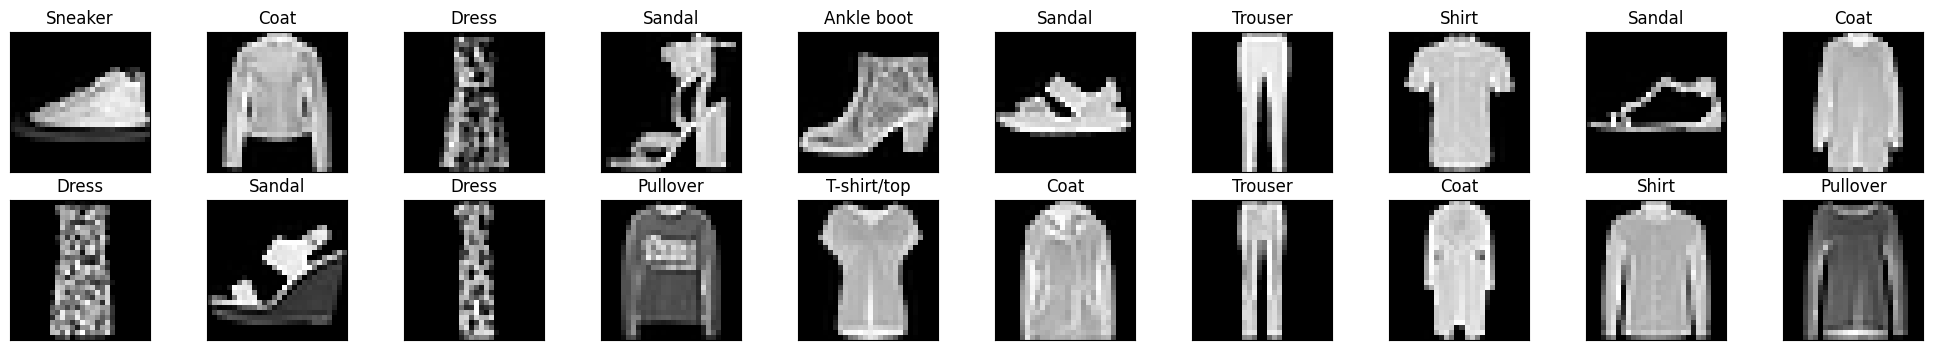

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(classes[labels[idx]])

## Архитектура модели

Мы создадим MLP (multilayer perceptron), который будем использовать для классификации данных, со следующими характеристиками:


* 3 линейных слоя с размерами 256 и 128;

* MLP принимает в качестве входных данных выпрямленное изображение (вектор длины 784) и выдает оценку принадлежности объекта к каждому из 10 классов.
---
Мы проверим влияние различных инициализаций на эту 3-слойную нейронную сеть, обученную с активациями ReLU и оптимизатором Adam.  

Полученные выводы применимы и к другим нейронным сетям, включая различные активации и оптимизаторы.

---

### All Zeros or Ones
Следуя принципам бритвы Оккама ([Occam's razor](https://en.wikipedia.org/wiki/Occam's_razor)), вы могли бы естестевенно подумать, что достаточно проиницализировать все веса нулем или единицей.

При одинаковом весе все нейроны в каждом слое выдают одинаковый результат.  Это затрудняет обучение, так как непонятно, какие именно веса в какую сторону нужно менять.

Давайте сравним функции потерь для двух моделей, проинициализированных (1) нулями и (2) единицами.

Ниже мы используем Pytorch's [nn. init](https://pytorch.org/docs/stable/nn.html#torch-nn-init), чтобы проинициализировать веса каждого линейного слоя константной. Библиотека init предоставляет ряд функций инициализации, которые дают возможность инициализировать веса каждого слоя в соответствии с его типом.
Для линейного слоя веса инициализируются следующим образом:

>```
if isinstance(m, nn.Linear):
    nn.init.constant_(m.weight, constant_weight)
    nn.init.constant_(m.bias, 0)
```

где `constant_weight` - значение константы (в нашем случае 0 или 1).

**Задание**: определите модель c описанной выше архитуктурой

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# define the NN architecture
class Net(nn.Module):

  #init - при вызове экземпляров Создаются новые объекты слоёв: новый тензор весов [256, 784], [128, 256], [10, 128] (batch_size, parametrs) + Инициализация весов

    def __init__(self, hidden_1=256, hidden_2=128, constant_weight=None):
        super(Net, self).__init__()
        # linear layer (784 -> hidden_1)
        self.fc1 = nn.Linear(784, hidden_1) #=> новый тензор весов [256, 784] (256 лк с 784 признаками)
        # linear layer (hidden_1 -> hidden_2)
        self.fc2 = nn.Linear(hidden_1, hidden_2) #128 лк с 256 признаками
        # linear layer (hidden_2 -> 10)
        self.fc3 = nn.Linear(hidden_2, 10) #10 лк с 128 признаками
        # dropout layer (p=0.2)
        self.dropout = nn.Dropout(p=0.2)

        # initialize the weights to a specified, constant value
        if(constant_weight is not None):
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.constant_(m.weight, constant_weight)
                    nn.init.constant_(m.bias, 0)

    #Когда ты вызываешь model_0(data) или model_1(data), выполняется один и тот же алгоритм, но с разными весами:

    def forward(self, x):
        # 1. Преобразуем изображение в вектор
        x = x.view(-1, 28 * 28)
        # 2. Линейное преобразование + ReLU
        x = F.relu(self.fc1(x))
        # 3. Dropout (только во время обучения)
        x = self.dropout(x)
        # 4. Ещё один слой
        x = F.relu(self.fc2(x))
        # add dropout layer
        x = self.dropout(x)
        # 6. Выходной слой (без активации)
        x = self.fc3(x) # Возвращается тензор [batch_size, 10] - 10 чисел логитов
        return x


### Сравнение поведения модели

Ниже мы используем функцию `.compare_init_weights`, чтобы сравнить функции потерь на обучении и тесте для двух моделей: `model_0` и `model_1`.  Эта функция принимает список моделей (каждая с различными начальными весами), название создаваемого графика, а также загрузчики обучающих и тестовых наборов данных. Для каждой заданной модели эта функцию построит график лосса га обучения для первых 100 батчей и выведет точность валидации после 2 эпох обучения.

*Примечание: Если вы использовали батчи меньшего размера, вы можете увеличить количество эпох здесь, чтобы лучше сравнить, как ведут себя модели после просмотра нескольких сотен изображений.*


**Задание**: Допишите обучение модели и запустите ячейки ниже, чтобы увидеть разницу между инициализациями всеми нулями и всеми единицами.

In [ ]:
# Создаём две нейронные сети с постоянными начальными весами:(т.е 1 экземлпрял класса - 1 нейросеть)
# ГДЕ, в каждом экземпляре(нейросети) : init - Создаются новые объекты слоёв: новый тензор весов [256, 784], [128, 256], [10, 128] (batch_size, parametrs) + Инициализация весов;
# - model_0: все веса инициализированы нулями
# - model_1: все веса инициализированы единицами
# Это позволяет сравнить, как плохая инициализация влияет на обучение.

model_0 = Net(constant_weight=0)  # модель с нулевыми весами. Все нейроны выдают 0 → градиенты 0 → не учится.
model_1 = Net(constant_weight=1)  # модель с единичными весами. Активации огромные → ReLU "насыщены" → градиенты маленькие → учится плохо.

# явно задаем только constant_weight, а остальные параметры класса берутся из значений по умолчанию.

In [ ]:
def _get_loss_acc(model, train_loader, valid_loader):
    """
    Обучает модель и возвращает историю потерь и точность на валидации.
    """
    # Количество эпох обучения (2 достаточно, чтобы увидеть разницу)
    n_epochs = 2

    # Скорость обучения (learning rate) — маленькая, чтобы не "перепрыгнуть" минимум
    learning_rate = 0.001

    # Функция потерь для задачи классификации: CrossEntropyLoss
    # Она автоматически применяет softmax к выходам модели и вычисляет логарифмическую потерю.
    criterion = nn.CrossEntropyLoss()

    # Оптимизатор Adam — адаптивный метод, хорошо работает "из коробки"
    optimizer = torch.optim.Adam(model.parameters(), learning_rate)

    # Список для хранения значения функции потерь на каждом батче (для графика)
    loss_batch = []

    # --------------------------------------------------
    # Цикл по эпохам: проходим по всему датасету n_epochs раз
    for epoch in range(1, n_epochs + 1):
        # Переменная для отслеживания общей потери за эпоху (не используется в графике, но можно оставить)
        train_loss = 0.0

        ########################
        # ОБУЧЕНИЕ МОДЕЛИ       #
        ########################
        # Цикл по батчам обучающего набора
        for data, target in train_loader:
            # Обнуляем градиенты всех параметров модели перед новым шагом
            # (иначе градиенты будут накапливаться от предыдущих шагов)
            optimizer.zero_grad()

            # Прямой проход: передаём входные данные через модель и получаем предсказания (логиты)
            output = model(data)

            # Вычисляем значение функции потерь для текущего батча
            # criterion ожидает: (логиты, истинные метки)
            loss = criterion(output, target)

            # Обратный проход: вычисляем градиенты потери по всем параметрам модели
            loss.backward()

            # Выполняем один шаг оптимизации: обновляем веса модели в направлении антиградиента
            optimizer.step()

            # Сохраняем скалярное значение потери для текущего батча (для последующего построения графика)
            # .item() преобразует тензор размера [1] в обычное число Python
            loss_batch.append(loss.item())
    # --------------------------------------------------

    # После обучения в течение 2 эпох оцениваем качество модели на валидационной выборке
    # correct — счётчик правильных предсказаний
    correct = 0
    # total — общее количество примеров
    total = 0


    # После обучения в течение 2 эпох оцениваем точность модели на валидационной выборке
    correct = 0   # Счётчик количества правильных предсказаний
    total = 0     # Общее количество обработанных примеров

    # Проходим по всем батчам валидационного набора данных
    for data, target in valid_loader:
        # Прямой проход: передаём входные данные через модель и получаем логиты (сырые предсказания)
        output = model(data)

        # Находим предсказанный класс как индекс с максимальным значением логита
        # torch.max возвращает (значения, индексы); нам нужны только индексы → используем _
        _, predicted = torch.max(output.data, 1)

        # Увеличиваем общее количество обработанных примеров на размер текущего батча
        total += target.size(0)

        # Подсчитываем, сколько предсказаний совпало с истинными метками
        # (predicted == target) даёт тензор из True/False,
        # .sum() считает количество True (как целые числа),
        # результат — тензор, поэтому позже вызовем .item()
        correct += (predicted == target).sum()

    # Вычисляем точность как долю правильных предсказаний от общего числа примеров
    # correct — это тензор, поэтому используем .item(), чтобы получить обычное число (скаляр)
    valid_acc = correct.item() / total

    # Возвращаем историю потерь (по батчам) и итоговую точность на валидации
    return loss_batch, valid_acc

In [ ]:
def compare_init_weights(
        model_list,
        plot_title,
        train_loader,
        valid_loader,
        plot_n_batches=100):
    """
    Сравнивает несколько моделей: строит графики потерь и выводит точность.
    """
    # Список цветов для графиков (до 6 моделей)
    colors = ['r', 'b', 'g', 'c', 'y', 'k']
    # Список для хранения точностей с метками
    label_accs = []
    # Список для хранения финальных потерь с метками
    label_loss = []

    # Проверка: не слишком ли много моделей для отображения
    assert len(model_list) <= len(colors), 'Слишком много моделей для отображения'

    # Цикл по всем моделям из списка
    for i, (model, label) in enumerate(model_list):
        # Сохраняем веса модели в файл (может использоваться в тестах)
        torch.save(model.state_dict(), f"{label}.pt")

        # Обучаем модель и получаем историю потерь и точность
        loss, val_acc = _get_loss_acc(model, train_loader, valid_loader)

        # Строим график потерь: только первые plot_n_batches значений
        plt.plot(loss[:plot_n_batches], colors[i], label=label)
        # Сохраняем точность для вывода
        label_accs.append((label, val_acc))
        # Сохраняем финальную потерю для вывода
        label_loss.append((label, loss[-1]))

    # Настройка графика
    plt.title(plot_title)                # заголовок
    plt.xlabel('Батчи')               # подпись оси X
    plt.ylabel('Потеря')              # подпись оси Y
    # Легенда справа от графика, чтобы не закрывала линии
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()  # отображаем график

    # Выводим результаты после 2 эпох
    print('После 2 эпох:')
    print('Точность на валидации')
    for label, val_acc in label_accs:
        # Форматируем: 7 знаков всего, 3 после точки, например: " 10.000%"
        print('  {:7.3f}% -- {}'.format(val_acc*100, label))
    print('Обучающая потеря')
    for label, loss in label_loss:
        # Форматируем: 7 знаков всего, 3 после точки, например: "  2.303"
        print('  {:7.3f}  -- {}'.format(loss, label))


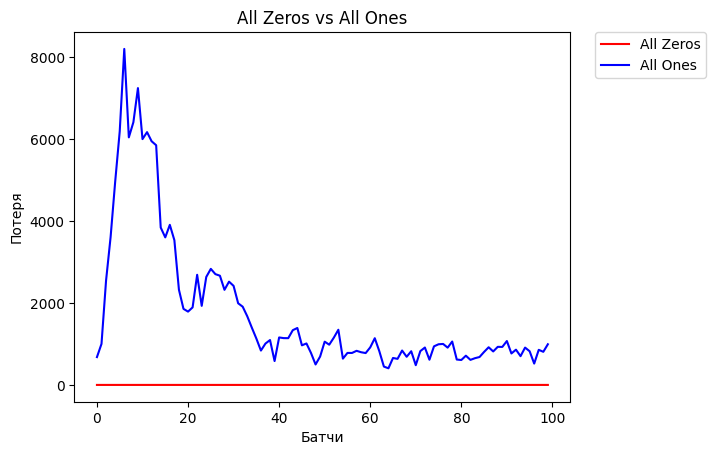

После 2 эпох:
Точность на валидации
    9.617% -- All Zeros
   10.342% -- All Ones
Обучающая потеря
    2.303  -- All Zeros
   95.267  -- All Ones


In [ ]:
# Формируем список моделей с метками
# ВАЖНО: названия меток ('All Zeros', 'All Ones') должны быть именно такими —
# на них завязаны автоматические тесты!
model_list = [
    (model_0, 'All Zeros'),   # модель с нулевыми весами
    (model_1, 'All Ones')     # модель с единичными весами
]

# Запускаем сравнение
compare_init_weights(
    model_list,
    'All Zeros vs All Ones',  # заголовок графика
    train_loader,             # загрузчик обучающих данных
    valid_loader              # загрузчик валидационных данных
)

Как вы можете видеть, точность близка к случайному угадыванию как для нулей, так и для единиц, около 10%.

Нейронной сети трудно определить, какие веса должны быть изменены, так как нейроны имеют одинаковый выход для каждого слоя.  Чтобы избежать нейронов с одинаковым выходом, давайте использовать уникальные веса.  Мы также можем случайным образом выбрать веса, чтобы избежать застревания в локальном минимуме для каждого запуска.

Хорошим решением для получения этих случайных весов является выборка из однородного распределения.

# Воспроизводимость результатов

Для того, чтобы запуск в колабе и запуск в пайплайных были более-менее воспроизводимы, воспользуйтесь следующей функцией. См так же [заметку](https://pytorch.org/docs/stable/notes/randomness.html) о воспроизводимости в доке pytorch

In [ ]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch

    if torch.__version__ >= '1.8':
        torch.use_deterministic_algorithms(True)
    else:
        torch.set_deterministic(True)

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True


### Равномерное распределение
[Равномерное распределение](https://en.wikipedia.org/wiki/Uniform_distribution) имеет равную вероятность выбора любого числа из набора. Мы будем выбирать из непрерывного распределения, поэтому вероятность выбора одного и того же числа невелика.

### Uniform Initialization, Baseline


Давайте посмотрим, насколько хорошо нейронная сеть тренируется с использованием равномерной инициализации весов, где параметры равномерного распределения `a=0.0` и `b=1.0`. Мы рассмотрим другой способ инициализации весов нейросети (помимо использованного в коде класса Net). Чтобы инициализировать веса вне определения модели, вы можете:
1. Определить функцию, которая инициализирует веса нужных слоев (в нашем случае - линейных)

2. Инициализировать модель, используя `model.apply(fn)`, которая применяет функцию `fn` к каждому слою модели.

Для равномерной инициализации весов нашей модели используйте `weight.data.uniform_`.

**Задание:** допишите функцию равномерной инициализации весов

In [ ]:
# Принимает модуль (слой) и применяет к нему заданную инициализацию весов
def weights_init_uniform(m):
    # Получаем имя класса текущего модуля (например, 'Linear', 'Conv2d', 'Dropout' и т.д.)
    classname = m.__class__.__name__

    # Проверяем, является ли текущий модуль полносвязным слоем (Linear)
    if classname.find('Linear') != -1:
        # Инициализируем веса этого слоя из равномерного распределения на отрезке [0.0, 1.0]
        # .data.uniform_(a, b) — заменяет значения тензора весов случайными числами из Uniform(a, b)
        m.weight.data.uniform_(0.0, 1.0)

        # Инициализируем смещения (bias) нулями (стандартная практика)
        # Без этого bias может остаться случайным (в зависимости от реализации nn.Linear)
        m.bias.data.fill_(0.0)

In [ ]:
# Создаём новую модель с теми же архитектурными параметрами, но без фиксированной инициализации
model_uniform = Net()  # здесь constant_weight=None → веса инициализируются по умолчанию в PyTorch

# Устанавливаем фиксированный seed для воспроизводимости результатов
seed_everything(42)

# Применяем нашу функцию инициализации ко всем слоям модели
# .apply(fn) рекурсивно вызывает fn для каждого подмодуля (включая fc1, fc2, fc3)
model_uniform.apply(weights_init_uniform)

Net(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

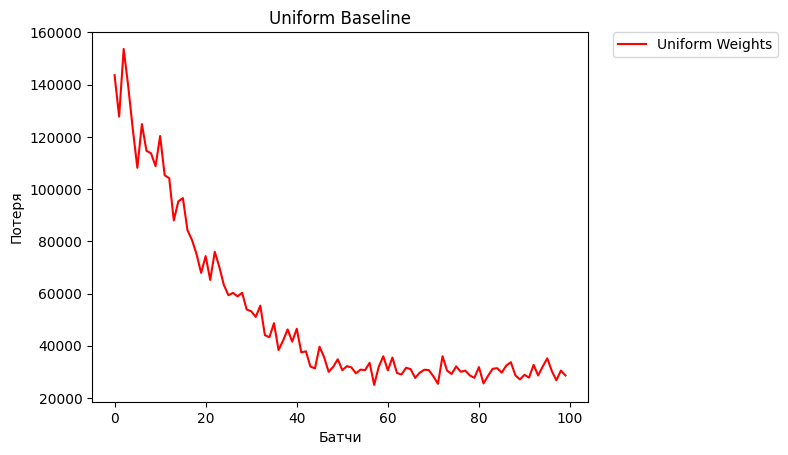

После 2 эпох:
Точность на валидации
   42.400% -- Uniform Weights
Обучающая потеря
   16.910  -- Uniform Weights


In [ ]:
# Оцениваем поведение модели с равномерной инициализацией
compare_init_weights(
    [(model_uniform, 'Uniform Weights')],  # не менять название — на него завязаны тесты
    'Uniform Baseline',                    # заголовок графика
    train_loader,                          # загрузчик обучающих данных
    valid_loader                           # загрузчик валидационных данных
)

---
График потерь показывает, что нейронная сеть учится, чего она не делала со всеми нулями или со всеми единицами. Мы движемся в правильном направлении!

## Общее правило инициализации весов
Общее правило для инициализации весов в нейронной сети состоит в том, чтобы установить их близкими к нулю, но не слишком маленькими.
>Хорошая практика заключается в том, чтобы инициализировать веса в диапазоне $[- y, y]$, где $y=1/\sqrt{n}$  
($n$ - это число входов в данный нейрон).

Давайте посмотрим, верно ли это: центрируем наш равномерный диапазон относительно нуля, сдвинув его на 0,5.  Это даст нам диапазон [-0.5, 0.5] равномерного распределения.

**Задание:** поменяйте функцию равномерной инициализации весов, чтобы распределение весов было в диапозоне [-0.5, 0.5].

In [ ]:
# Принимает модуль (слой) и применяет заданную инициализацию весов
def weights_init_uniform_center(m):
    # Получаем имя класса текущего модуля (например, 'Linear', 'Dropout' и т.д.)
    classname = m.__class__.__name__

    # Проверяем, является ли текущий модуль полносвязным слоем (Linear)
    if classname.find('Linear') != -1:
        # Инициализируем веса из равномерного распределения на отрезке [-0.5, 0.5]
        # uniform_(a, b) заполняет тензор случайными числами из [a, b)
        m.weight.data.uniform_(-0.5, 0.5)

        # Инициализируем смещения (bias) нулями — стандартная практика
        m.bias.data.fill_(0.0)


# Создаём новую модель с архитектурой по умолчанию (без фиксированной инициализации)
model_centered = Net()

# Устанавливаем фиксированный seed для воспроизводимости результатов
seed_everything(42)

# Применяем функцию центрированной инициализации ко всем слоям модели
model_centered.apply(weights_init_uniform_center)

Net(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [ ]:
# Вторая функция: инициализация по общему правилу y = 1 / sqrt(n_in)
# Принимает модуль и применяет инициализацию в диапазоне [-y, y]
def weights_init_uniform_rule(m):
    # Получаем имя класса модуля
    classname = m.__class__.__name__

    # Обрабатываем только полносвязные слои
    if classname.find('Linear') != -1:
        # Вычисляем количество входов в этот слой (fan_in)
        # Для nn.Linear: weight.shape = [out_features, in_features]
        n_inputs = m.weight.data.size(1)  # размерность "входов" = количество столбцов

        # Вычисляем y = 1 / sqrt(n_inputs) — граница интервала
        y = 1.0 / (n_inputs ** 0.5)

        # Инициализируем веса из равномерного распределения на отрезке [-y, y]
        m.weight.data.uniform_(-y, y)

        # Инициализируем смещения нулями
        m.bias.data.fill_(0.0)


# Создаём ещё одну новую модель
model_rule = Net()

# Применяем инициализацию по общему правилу
# (seed уже установлен выше, но можно повторить для надёжности)
seed_everything(42)
model_rule.apply(weights_init_uniform_rule)

Net(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

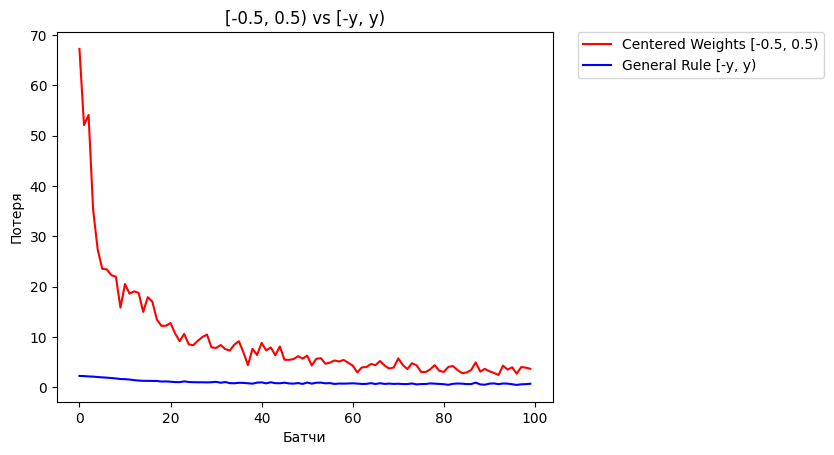

После 2 эпох:
Точность на валидации
   74.442% -- Centered Weights [-0.5, 0.5)
   84.575% -- General Rule [-y, y)
Обучающая потеря
    1.225  -- Centered Weights [-0.5, 0.5)
    0.438  -- General Rule [-y, y)


In [ ]:
# Формируем список моделей для сравнения
# ВАЖНО: названия меток должны быть именно такими — на них завязаны автоматические тесты!
model_list = [
    (model_centered, 'Centered Weights [-0.5, 0.5)'),   # центрированная инициализация
    (model_rule, 'General Rule [-y, y)')               # инициализация по правилу 1/sqrt(n)
]

# Запускаем сравнение: строим графики потерь и выводим точность
compare_init_weights(
    model_list,
    '[-0.5, 0.5) vs [-y, y)',  # заголовок графика
    train_loader,              # загрузчик обучающих данных
    valid_loader               # загрузчик валидационных данных
)

Такое поведение действительно многообещающе! Мало того, что лосс уменьшается, но, кажется, это происходит очень быстро; всего через две эпохи мы получаем довольно высокую точность на тесте. Это должно дать вам некоторое представление о том, почему хорошая инициализация весов действительно может помочь тренировочному процессу!

---

Равномерное распределение имеет одинаковый шанс выбрать *любое значение* в диапазоне. Что, если мы используем распределение, которое имеет более высокий шанс выбрать числа ближе к 0?  Давайте рассмотрим на нормальное распределение.

### Hормальное распределение
В отличие от равномерного распределения, [нормальное распределение](https://en.wikipedia.org/wiki/Normal_distribution) имеет более высокую вероятность выбора числа, близкого к среднему значению.

**Задание:** добавьте нормальное распределение:
как стандартное отклонение выберите $y=1/\sqrt{n}$

In [ ]:
## complete this function

def weights_init_normal(m):
    '''Принимает модуль и инициализирует все полносвязные слои весами,
       взятыми из нормального распределения.'''

    # Получаем имя класса текущего модуля (например, 'Linear', 'Dropout' и т.д.)
    classname = m.__class__.__name__

    # Проверяем, является ли модуль полносвязным слоем (Linear)
    if classname.find('Linear') != -1:
        # Вычисляем количество входов в слой (fan-in)
        # Для nn.Linear: weight.shape = [out_features, in_features]
        n_inputs = m.weight.data.size(1)

        # Вычисляем стандартное отклонение по правилу: y = 1 / sqrt(n_inputs)
        std = 1.0 / (n_inputs ** 0.5)

        # Инициализируем веса из нормального распределения N(0, std^2)
        # .normal_(mean, std) — заполняет тензор случайными числами из нормального распределения
        m.weight.data.normal_(0.0, std)

        # Инициализируем смещения (bias) нулями
        m.bias.data.fill_(0.0)


In [ ]:
## -- no need to change code below this line -- ##

# Создаём новую модель с инициализацией по правилу для равномерного распределения
model_uniform_rule = Net()

seed_everything(42)
model_uniform_rule.apply(weights_init_uniform_rule)

# Создаём новую модель с инициализацией по правилу для нормального распределения
model_normal_rule = Net()

seed_everything(42)
model_normal_rule.apply(weights_init_normal)

Net(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

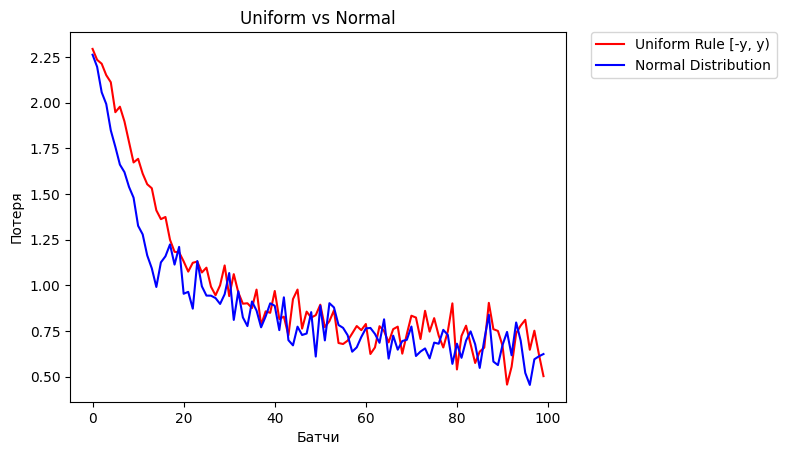

После 2 эпох:
Точность на валидации
   84.025% -- Uniform Rule [-y, y)
   84.417% -- Normal Distribution
Обучающая потеря
    0.533  -- Uniform Rule [-y, y)
    0.430  -- Normal Distribution


In [ ]:
model_list = [(model_uniform_rule, 'Uniform Rule [-y, y)'), # не надо менять название лейбла модели, на это завязаны тесты
              (model_normal_rule, 'Normal Distribution')]   # не надо менять название лейбла модели, на это завязаны тесты

compare_init_weights(model_list,
                             'Uniform vs Normal',
                             train_loader,
                             valid_loader)

Нормальное распределение дает нам довольно похожее поведение по сравнению с равномерным распределением в данном случае. Вероятно, это связано с тем, что наша сеть очень мала; более крупная нейронная сеть будет выбирать больше весовых значений из каждого из этих распределений, увеличивая эффект обоих стилей инициализации. В общем случае нормальное распределение приведет к улучшению качества модели.